In [ ]:
!pip install qiskit

Symulacja kanału kwantowego BB84

Wybrano plik QRNG: QNGFile10.dat

--- FIZYCZNE PARAMETRY ŚRODOWISKA ---
Błąd źródła (Laser) - domyślnie 0.01 (1%): 
Błąd światłowodu (Dekohorencja) - domyślnie 0.03 (3%): 
Błąd detektorów Boba (Dark counts) - domyślnie 0.01 (1%): 

Czy chcesz najpierw wygenerować tabele i wykresy analizy strategii Ewy? (t/n) [n]: t

Generowanie analizy statystycznej... (Proszę czekać, symulacja w toku)

RAPORT Z SYMULACJI: ATAK PROBABILISTYCZNY
Ilość fotonów w próbce: 1000 (dla każdego z punktów pomiarowych)
Szansa     | QBER (Losowa)   | QBER (Prosta)   | QBER (Skośna)   | Wiedza (Losowa)  | Wiedza (Prosta)  | Wiedza (Skośna) 
-------------------------------------------------------------------------------------------------------------------
    0%     |       3.60%      |       4.02%      |       3.82%      |        0.00%      |        0.00%      |        0.00%
    5%     |       3.56%      |       6.44%      |       5.28%      |        2.57%      |        3.82%      |        4.50%
   10%     |       

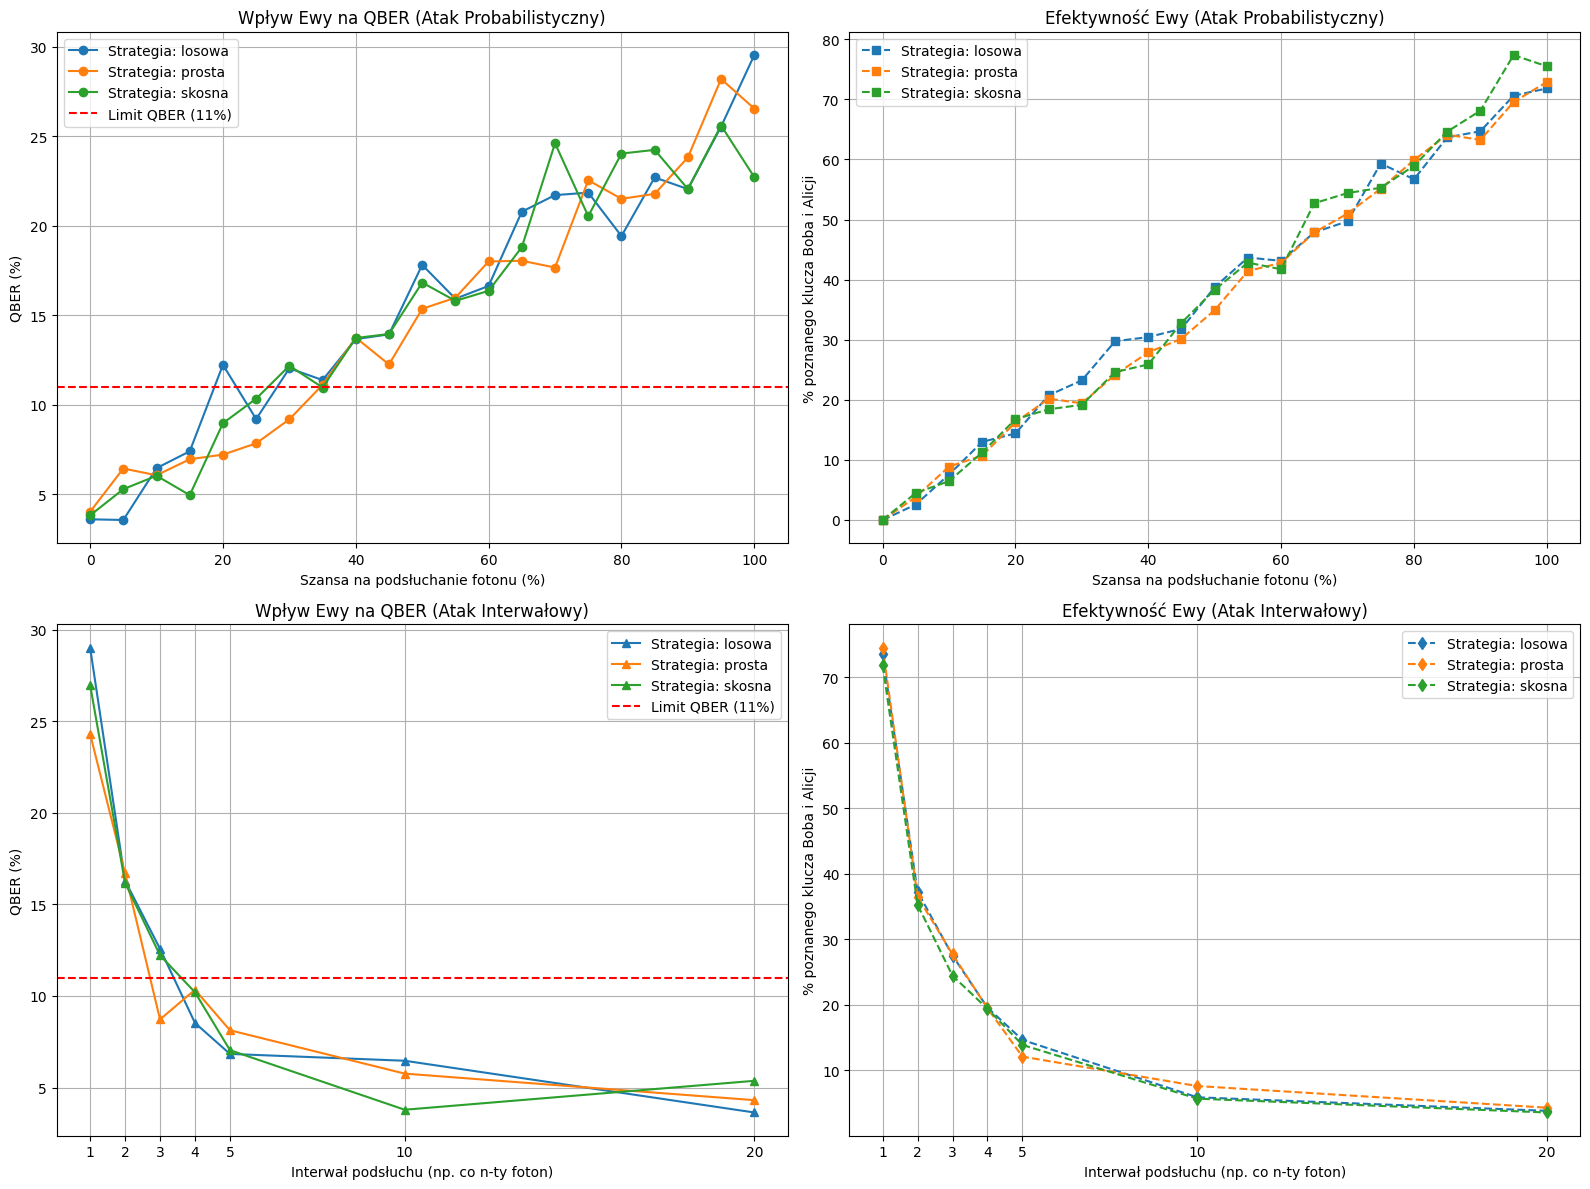


--- RĘCZNA SYMULACJA GŁÓWNA ---


KeyboardInterrupt: Interrupted by user

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

# ==========================================
# 1. MODUŁ LOSOWOŚCI (QRNG Z PLIKU)
# ==========================================
class QRNGFileGenerator:
    def __init__(self, filepath):
        self.filepath = filepath
        self.file = open(filepath, 'rb')
        losowy_start = random.randint(0, 1024)
        self.file.seek(losowy_start)
        self.buffer = 0
        self.bit_pos = 0

    def get_next_bit(self):
        if self.bit_pos == 0:
            byte = self.file.read(1)
            if not byte:
                self.file.seek(0)
                byte = self.file.read(1)
            self.buffer = int.from_bytes(byte, byteorder='big')
            self.bit_pos = 8
        self.bit_pos -= 1
        return (self.buffer >> self.bit_pos) & 1

    def close(self):
        self.file.close()


# Źródło fotonów idealne BB84

def alicja_przygotuj_fotony(ilosc_fotonow, qrng, source_error_rate=0.01):
    obwody_kwantowe = []
    bity_alicji = []
    bazy_alicji = []
    for _ in range(ilosc_fotonow):
        wartosc_bitu = qrng.get_next_bit()
        baza_pomiarowa = qrng.get_next_bit()
        bity_alicji.append(wartosc_bitu)
        bazy_alicji.append(baza_pomiarowa)

        qc = QuantumCircuit(1)
        if wartosc_bitu == 1: qc.x(0)
        if baza_pomiarowa == 1: qc.h(0)

        if random.random() < source_error_rate:
            qc.x(0)
        obwody_kwantowe.append(qc)
    return obwody_kwantowe, bity_alicji, bazy_alicji

# Podsłuch Ewy

def podsłuch_ewy(obwody_kwantowe, qrng, strategia='losowa', tryb='probabilistyczny', prawdopodobienstwo=0.1, start_krok=0, interwal=2):
    obwody_po_ewie = []
    bity_ewy = []
    bazy_ewy = []

    for i, qc in enumerate(obwody_kwantowe):
        podsłuchuje = False
        if tryb == 'probabilistyczny':
            if random.random() < prawdopodobienstwo: podsłuchuje = True
        elif tryb == 'sekwencyjny':
            if i >= start_krok: podsłuchuje = True
        elif tryb == 'interwalowy':
            if interwal > 0 and (i + 1) % interwal == 0: podsłuchuje = True

        if not podsłuchuje:
            obwody_po_ewie.append(qc.copy())
            bity_ewy.append(None)
            bazy_ewy.append(None)
            continue

        if strategia == 'prosta': baza = 0
        elif strategia == 'skosna': baza = 1
        else: baza = qrng.get_next_bit()

        bazy_ewy.append(baza)

        qc_ewa = qc.copy()
        if baza == 1: qc_ewa.h(0)
        wektor_stanu = Statevector(qc_ewa)
        zmierzony_wynik_str, _ = wektor_stanu.measure()
        zmierzony_bit = int(zmierzony_wynik_str)
        bity_ewy.append(zmierzony_bit)

        nowy_foton = QuantumCircuit(1)
        if zmierzony_bit == 1: nowy_foton.x(0)
        if baza == 1: nowy_foton.h(0)
        obwody_po_ewie.append(nowy_foton)

    return obwody_po_ewie, bity_ewy, bazy_ewy


# Kanał kwantowy

def kanal_kwantowy(obwody_kwantowe, channel_error_rate=0.03):
    obwody_po_przejsciu = []
    for qc in obwody_kwantowe:
        qc_kanal = qc.copy()
        if random.random() < channel_error_rate:
            rodzaj_bledu = random.choice(['X', 'Y', 'Z'])
            if rodzaj_bledu == 'X': qc_kanal.x(0)
            elif rodzaj_bledu == 'Y': qc_kanal.y(0)
            elif rodzaj_bledu == 'Z': qc_kanal.z(0)
        obwody_po_przejsciu.append(qc_kanal)
    return obwody_po_przejsciu

# Pomiar

def bob_pomiar(obwody_po_kanale, qrng, detector_error_rate=0.01):
    bazy_boba = []
    wyniki_boba = []
    for qc in obwody_po_kanale:
        baza_pomiarowa = qrng.get_next_bit()
        bazy_boba.append(baza_pomiarowa)

        qc_pomiar = qc.copy()
        if baza_pomiarowa == 1: qc_pomiar.h(0)

        wektor_stanu = Statevector(qc_pomiar)
        zmierzony_wynik_str, _ = wektor_stanu.measure()
        bit = int(zmierzony_wynik_str)

        if random.random() < detector_error_rate:
            bit ^= 1

        wyniki_boba.append(bit)
    return wyniki_boba, bazy_boba

# Elementy warstwy klasycznej

def uzgodnij_klucz(bity_alicji, bazy_alicji, bity_boba, bazy_boba):
    klucz_alicji, klucz_boba = [], []
    for i in range(len(bazy_alicji)):
        if bazy_alicji[i] == bazy_boba[i]:
            klucz_alicji.append(bity_alicji[i])
            klucz_boba.append(bity_boba[i])
    return klucz_alicji, klucz_boba

def korekcja_bledow(klucz_alicji, klucz_boba, rozmiar_bloku=4):
    ostateczny_klucz_alicji, ostateczny_klucz_boba = [], []
    for i in range(0, len(klucz_alicji), rozmiar_bloku):
        blok_a = klucz_alicji[i:i+rozmiar_bloku]
        blok_b = klucz_boba[i:i+rozmiar_bloku]
        if len(blok_a) < rozmiar_bloku: continue

        if sum(blok_a) % 2 == sum(blok_b) % 2:
            ostateczny_klucz_alicji.extend(blok_a[:-1])
            ostateczny_klucz_boba.extend(blok_b[:-1])
    return ostateczny_klucz_alicji, ostateczny_klucz_boba

# Wykresy

def generuj_wykresy(qrng, p_zrodla, p_kanalu, p_detektora):
    print("\nGenerowanie analizy statystycznej... (Proszę czekać, symulacja w toku)")

    ilosc_symulacji = 1000
    strategie = ['losowa', 'prosta', 'skosna']

    # --- A. SYMULACJA PROBABILISTYCZNA (CO 5%) ---
    prawdopodobienstwa = [i/20.0 for i in range(21)]
    wyniki_qber_prob = {strat: [] for strat in strategie}
    wyniki_wiedza_prob = {strat: [] for strat in strategie}

    print("\n===========================================================================================================")
    print(f"RAPORT Z SYMULACJI: ATAK PROBABILISTYCZNY")
    print(f"Ilość fotonów w próbce: {ilosc_symulacji} (dla każdego z punktów pomiarowych)")
    print("===========================================================================================================")
    print(f"{'Szansa':<10} | {'QBER (Losowa)':<15} | {'QBER (Prosta)':<15} | {'QBER (Skośna)':<15} | {'Wiedza (Losowa)':<16} | {'Wiedza (Prosta)':<16} | {'Wiedza (Skośna)':<16}")
    print("-" * 115)

    for p_ewy in prawdopodobienstwa:
        w_qber = []
        w_wiedza = []
        for strat in strategie:
            f_alicji, b_alicji, bazy_a = alicja_przygotuj_fotony(ilosc_symulacji, qrng, p_zrodla)
            f_ewy, b_ewy, bazy_e = podsłuch_ewy(f_alicji, qrng, strategia=strat, tryb='probabilistyczny', prawdopodobienstwo=p_ewy)
            f_boba = kanal_kwantowy(f_ewy, channel_error_rate=p_kanalu)
            b_boba, bazy_b = bob_pomiar(f_boba, qrng, detector_error_rate=p_detektora)

            k_alicji, k_boba = uzgodnij_klucz(b_alicji, bazy_a, b_boba, bazy_b)

            bledy = sum(1 for a, b in zip(k_alicji, k_boba) if a != b)
            qber = (bledy / len(k_alicji)) * 100 if len(k_alicji) > 0 else 0
            wyniki_qber_prob[strat].append(qber)
            w_qber.append(qber)

            poprawne_ewy = 0
            for i in range(len(bazy_a)):
                if bazy_a[i] == bazy_b[i] and b_ewy[i] is not None:
                    if b_ewy[i] == b_alicji[i]:
                        poprawne_ewy += 1

            wiedza = (poprawne_ewy / len(k_alicji)) * 100 if len(k_alicji) > 0 else 0
            wyniki_wiedza_prob[strat].append(wiedza)
            w_wiedza.append(wiedza)

        print(f"{p_ewy*100:>5.0f}%     | {w_qber[0]:>10.2f}%      | {w_qber[1]:>10.2f}%      | {w_qber[2]:>10.2f}%      | {w_wiedza[0]:>11.2f}%      | {w_wiedza[1]:>11.2f}%      | {w_wiedza[2]:>11.2f}%")

    # --- B. SYMULACJA INTERWAŁOWA (RÓŻNE CZĘSTOTLIWOŚCI) ---
    # Posortowane od najczęstszego (co 1) do najrzadszego (co 20) dla lepszego wykresu
    interwaly = [1, 2, 3, 4, 5, 10, 20]

    wyniki_qber_int = {strat: [] for strat in strategie}
    wyniki_wiedza_int = {strat: [] for strat in strategie}

    print("\n===========================================================================================================")
    print(f"RAPORT Z SYMULACJI: ATAK INTERWAŁOWY")
    print(f"Ilość fotonów w próbce: {ilosc_symulacji} (dla każdego z punktów pomiarowych)")
    print("===========================================================================================================")
    print(f"{'Interwał':<10} | {'QBER (Losowa)':<15} | {'QBER (Prosta)':<15} | {'QBER (Skośna)':<15} | {'Wiedza (Losowa)':<16} | {'Wiedza (Prosta)':<16} | {'Wiedza (Skośna)':<16}")
    print("-" * 115)

    for inter in interwaly:
        w_qber = []
        w_wiedza = []
        for strat in strategie:
            f_alicji, b_alicji, bazy_a = alicja_przygotuj_fotony(ilosc_symulacji, qrng, p_zrodla)
            f_ewy, b_ewy, bazy_e = podsłuch_ewy(f_alicji, qrng, strategia=strat, tryb='interwalowy', interwal=inter)
            f_boba = kanal_kwantowy(f_ewy, channel_error_rate=p_kanalu)
            b_boba, bazy_b = bob_pomiar(f_boba, qrng, detector_error_rate=p_detektora)

            k_alicji, k_boba = uzgodnij_klucz(b_alicji, bazy_a, b_boba, bazy_b)

            bledy = sum(1 for a, b in zip(k_alicji, k_boba) if a != b)
            qber = (bledy / len(k_alicji)) * 100 if len(k_alicji) > 0 else 0
            wyniki_qber_int[strat].append(qber)
            w_qber.append(qber)

            poprawne_ewy = 0
            for i in range(len(bazy_a)):
                if bazy_a[i] == bazy_b[i] and b_ewy[i] is not None:
                    if b_ewy[i] == b_alicji[i]:
                        poprawne_ewy += 1

            wiedza = (poprawne_ewy / len(k_alicji)) * 100 if len(k_alicji) > 0 else 0
            wyniki_wiedza_int[strat].append(wiedza)
            w_wiedza.append(wiedza)

        etykieta = f"co {inter} bit"
        print(f"{etykieta:<10} | {w_qber[0]:>10.2f}%      | {w_qber[1]:>10.2f}%      | {w_qber[2]:>10.2f}%      | {w_wiedza[0]:>11.2f}%      | {w_wiedza[1]:>11.2f}%      | {w_wiedza[2]:>11.2f}%")

    # --- C. RYSOWANIE SIATKI WYKRESÓW (2x2) ---
    fig, axs = plt.subplots(2, 2, figsize=(16, 12))
    os_x_prob = [p*100 for p in prawdopodobienstwa]

    # Panel 1: QBER Probabilistyczny
    for strat in strategie:
        axs[0,0].plot(os_x_prob, wyniki_qber_prob[strat], marker='o', label=f'Strategia: {strat}')
    axs[0,0].set_title('Wpływ Ewy na QBER (Atak Probabilistyczny)')
    axs[0,0].set_xlabel('Szansa na podsłuchanie fotonu (%)')
    axs[0,0].set_ylabel('QBER (%)')
    axs[0,0].axhline(y=11, color='r', linestyle='--', label='Limit QBER (11%)')
    axs[0,0].grid(True); axs[0,0].legend()

    # Panel 2: Wiedza Probabilistyczna
    for strat in strategie:
        axs[0,1].plot(os_x_prob, wyniki_wiedza_prob[strat], marker='s', linestyle='--', label=f'Strategia: {strat}')
    axs[0,1].set_title('Efektywność Ewy (Atak Probabilistyczny)')
    axs[0,1].set_xlabel('Szansa na podsłuchanie fotonu (%)')
    axs[0,1].set_ylabel('% poznanego klucza Boba i Alicji')
    axs[0,1].grid(True); axs[0,1].legend()

    # Panel 3: QBER Interwałowy (Oś X = Wartość interwału)
    for strat in strategie:
        axs[1,0].plot(interwaly, wyniki_qber_int[strat], marker='^', label=f'Strategia: {strat}')
    axs[1,0].set_title('Wpływ Ewy na QBER (Atak Interwałowy)')
    axs[1,0].set_xlabel('Interwał podsłuchu (np. co n-ty foton)')
    axs[1,0].set_ylabel('QBER (%)')
    axs[1,0].set_xticks(interwaly) # Wyraźne oznaczenie punktów na osi
    axs[1,0].axhline(y=11, color='r', linestyle='--', label='Limit QBER (11%)')
    axs[1,0].grid(True); axs[1,0].legend()

    # Panel 4: Wiedza Interwałowa (Oś X = Wartość interwału)
    for strat in strategie:
        axs[1,1].plot(interwaly, wyniki_wiedza_int[strat], marker='d', linestyle='--', label=f'Strategia: {strat}')
    axs[1,1].set_title('Efektywność Ewy (Atak Interwałowy)')
    axs[1,1].set_xlabel('Interwał podsłuchu (np. co n-ty foton)')
    axs[1,1].set_ylabel('% poznanego klucza Boba i Alicji')
    axs[1,1].set_xticks(interwaly) # Wyraźne oznaczenie punktów na osi
    axs[1,1].grid(True); axs[1,1].legend()

    plt.tight_layout()
    plt.show()

# ==========================================
# TEST ZINTEGROWANY
# ==========================================
if __name__ == "__main__":
    lista_plikow = [f for f in os.listdir('.') if f.endswith('.dat')]
    if not lista_plikow and os.path.exists('qng'):
        lista_plikow = [os.path.join('qng', f) for f in os.listdir('qng') if f.endswith('.dat')]
    if not lista_plikow:
        raise FileNotFoundError("Brak plików z losowością! Przeciągnij pliki QNGFile.dat do Colaba.")

    wybrany_plik = random.choice(lista_plikow)
    print(f"Wybrano plik QRNG: {wybrany_plik}\n")

    # --- PARAMETRY SZUMU FIZYCZNEGO ---
    print("--- FIZYCZNE PARAMETRY ŚRODOWISKA ---")
    w1 = input("Błąd źródła (Laser) - domyślnie 0.01 (1%): ").strip()
    p_zrodla = float(w1) if w1 else 0.01

    w2 = input("Błąd światłowodu (Dekohorencja) - domyślnie 0.03 (3%): ").strip()
    p_kanalu = float(w2) if w2 else 0.03

    w3 = input("Błąd detektorów Boba (Dark counts) - domyślnie 0.01 (1%): ").strip()
    p_detektora = float(w3) if w3 else 0.01

    czy_wykresy = input("\nCzy chcesz najpierw wygenerować tabele i wykresy analizy strategii Ewy? (t/n) [n]: ").strip().lower()
    moj_qrng = QRNGFileGenerator(wybrany_plik)

    if czy_wykresy == 't':
        generuj_wykresy(moj_qrng, p_zrodla, p_kanalu, p_detektora)

    # RĘCZNA SYMULACJA GŁÓWNA
    print("\n--- RĘCZNA SYMULACJA GŁÓWNA ---")
    w_ilosc = input("Podaj ilość fotonów (Enter dla 50): ").strip()
    ilosc = int(w_ilosc) if w_ilosc else 50

    wybor_ewy = input("Czy Ewa ma podsłuchiwać linię? (t/n) [n]: ").strip().lower()
    czy_ewa_aktywna = (wybor_ewy == 't')

    if czy_ewa_aktywna:
        print("Dostępne strategie Ewy: 1='losowa' (Intercept-Resend), 2='prosta' (Z), 3='skosna' (X)")
        strat_input = input("Wybierz strategię (1/2/3) [1]: ").strip()
        strategia_ewy = 'prosta' if strat_input == '2' else 'skosna' if strat_input == '3' else 'losowa'

        print("Tryb podsłuchu: 1='probabilistyczny' (X% fotonów), 2='interwalowy' (co n-ty foton)")
        tryb_input = input("Wybierz tryb (1/2) [1]: ").strip()

        if tryb_input == '2':
            tryb_ewy = 'interwalowy'
            int_input = input("Podaj interwał (np. 2 dla co drugiego, 4 dla co czwartego) [2]: ").strip()
            interwal_ewy = int(int_input) if int_input else 2
            prob_ewy = 0.0
        else:
            tryb_ewy = 'probabilistyczny'
            interwal_ewy = 0
            prob_input = input("Podaj ułamek podsłuchiwanych fotonów (np. 0.2) [0.5]: ").strip()
            prob_ewy = float(prob_input) if prob_input else 0.5
    else:
        strategia_ewy, tryb_ewy, prob_ewy, interwal_ewy = 'losowa', 'probabilistyczny', 0.0, 0

    # 1. ALICJA
    fotony_alicji, bity_alicji, bazy_alicji = alicja_przygotuj_fotony(ilosc, moj_qrng, source_error_rate=p_zrodla)

    # 2. EWA
    if czy_ewa_aktywna:
        fotony_po_ewie, bity_ewy, bazy_ewy = podsłuch_ewy(
            fotony_alicji, moj_qrng, strategia=strategia_ewy, tryb=tryb_ewy, prawdopodobienstwo=prob_ewy, interwal=interwal_ewy)
    else:
        fotony_po_ewie = fotony_alicji
        bity_ewy = [None] * ilosc

    # 3. KANAŁ
    fotony_od_boba = kanal_kwantowy(fotony_po_ewie, channel_error_rate=p_kanalu)

    # 4. BOB
    bity_boba, bazy_boba = bob_pomiar(fotony_od_boba, moj_qrng, detector_error_rate=p_detektora)

    # 5. SIFTING
    surowy_klucz_alicji, surowy_klucz_boba = uzgodnij_klucz(bity_alicji, bazy_alicji, bity_boba, bazy_boba)
    ilosc_po_siftingu = len(surowy_klucz_alicji)
    bledy_przed_korekcja = sum(1 for a, b in zip(surowy_klucz_alicji, surowy_klucz_boba) if a != b)
    qber_poczatkowy = (bledy_przed_korekcja / ilosc_po_siftingu) * 100 if ilosc_po_siftingu > 0 else 0

    # 6. KOREKCJA
    czysty_klucz_alicji, czysty_klucz_boba = korekcja_bledow(surowy_klucz_alicji, surowy_klucz_boba, rozmiar_bloku=4)
    ilosc_po_korekcji = len(czysty_klucz_alicji)
    bledy_po_korekcji = sum(1 for a, b in zip(czysty_klucz_alicji, czysty_klucz_boba) if a != b)
    qber_koncowy = (bledy_po_korekcji / ilosc_po_korekcji) * 100 if ilosc_po_korekcji > 0 else 0

    print("\n==========================================")
    print(f"RAPORT Z TRANSMISJI ({ilosc} fotonów)")
    print(f"Szum: Laser {p_zrodla*100}% | Światłowód {p_kanalu*100}% | Detektory {p_detektora*100}%")
    if czy_ewa_aktywna:
        podsluchano_ile = sum(1 for b in bity_ewy if b is not None)
        print(f"EWA: Strategia '{strategia_ewy}', Tryb '{tryb_ewy}'. Przechwycono: {podsluchano_ile}/{ilosc}")
    print("==========================================")
    print(f"QBER SUROWY (Przed korekcją): {qber_poczatkowy:.2f}% ({bledy_przed_korekcja} błędów na {ilosc_po_siftingu} bitów)")
    print(f"QBER CZYSTY (Po korekcji):    {qber_koncowy:.2f}% ({bledy_po_korekcji} błędów na {ilosc_po_korekcji} bitów)")
    print("==========================================\n")

    moj_qrng.close()

Symulacja kanału kwantowego BBM92

Wybrano plik QRNG: QNGFile8.dat

--- FIZYCZNE PARAMETRY ŚRODOWISKA ---
Błąd źródła (Laser) - domyślnie 0.01 (1%): 
Błąd światłowodu (Dekohorencja) - domyślnie 0.03 (3%): 
Błąd detektorów Boba (Dark counts) - domyślnie 0.01 (1%): 

Czy chcesz najpierw wygenerować tabele i wykresy analizy strategii Ewy? (t/n) [n]: t

Generowanie analizy statystycznej... (Proszę czekać, symulacja w toku)

RAPORT Z SYMULACJI: ATAK PROBABILISTYCZNY
Ilość fotonów w próbce: 1000 (dla każdego z punktów pomiarowych)
Szansa     | QBER (Losowa)   | QBER (Prosta)   | QBER (Skośna)   | Wiedza (Losowa)  | Wiedza (Prosta)  | Wiedza (Skośna) 
-------------------------------------------------------------------------------------------------------------------
    0%     |       3.12%      |       2.24%      |       2.99%      |        0.00%      |        0.00%      |        0.00%
    5%     |       4.43%      |       3.57%      |       3.33%      |        3.08%      |        2.18%      |        2.15%
   10%     |       5

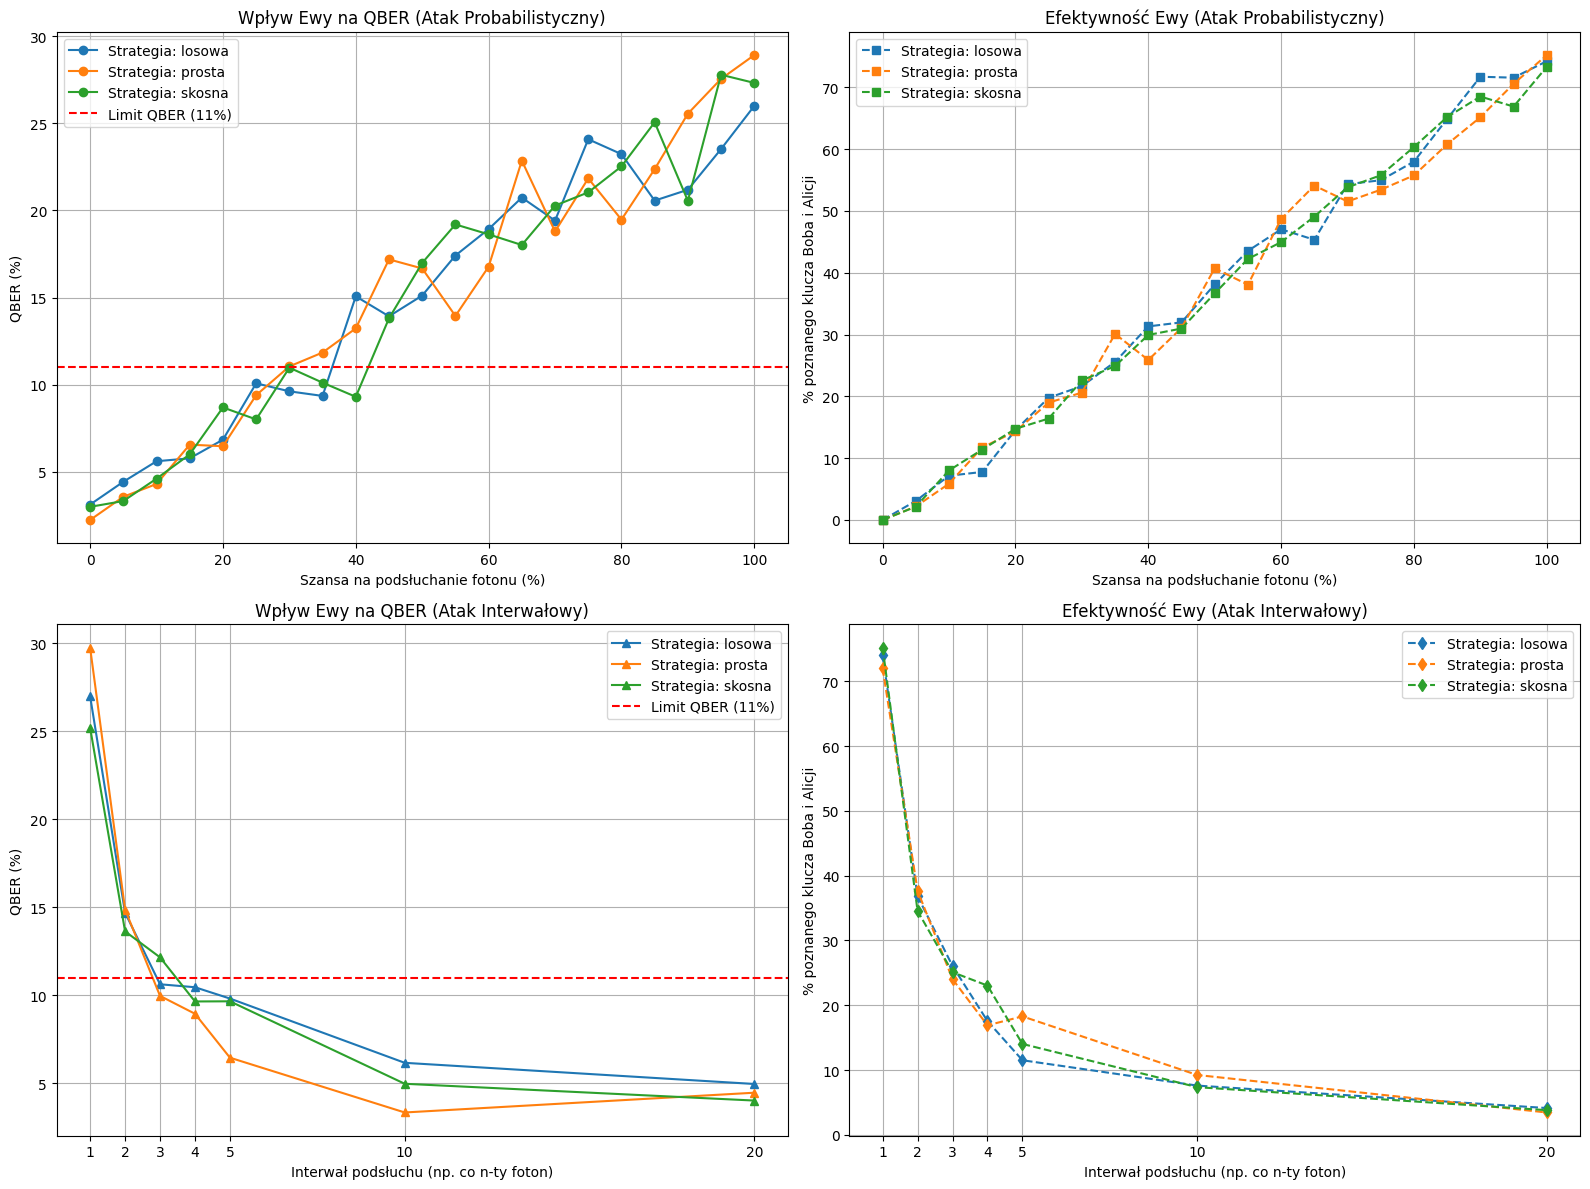


--- RĘCZNA SYMULACJA GŁÓWNA ---


KeyboardInterrupt: Interrupted by user

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

# Źródło BBM92

class QRNGFileGenerator:
    def __init__(self, filepath):
        self.filepath = filepath
        self.file = open(filepath, 'rb')
        losowy_start = random.randint(0, 1024)
        self.file.seek(losowy_start)
        self.buffer = 0
        self.bit_pos = 0

    def get_next_bit(self):
        if self.bit_pos == 0:
            byte = self.file.read(1)
            if not byte:
                self.file.seek(0)
                byte = self.file.read(1)
            self.buffer = int.from_bytes(byte, byteorder='big')
            self.bit_pos = 8
        self.bit_pos -= 1
        return (self.buffer >> self.bit_pos) & 1

    def close(self):
        self.file.close()

# Źródło fotonów BBM92

def zrodlo_splatane_i_alicja(ilosc_par, qrng, source_error_rate=0.01):
    bity_alicji = []
    bazy_alicji = []
    obwody_w_locie = []

    for _ in range(ilosc_par):
        baza_a = qrng.get_next_bit()
        bazy_alicji.append(baza_a)

        # Para splątana
        qc = QuantumCircuit(2) # 2 fotony
        qc.h(0)                # Superpozycja
        qc.cx(0, 1)            # Bramka CNOT - splątanie

        if random.random() < source_error_rate:
            qc.x(1)

        if baza_a == 1:
            qc.h(0) # Alicja obraca bazę na swoim fotonie

        sv = Statevector(qc)

        # kolaps fotonu Boba
        bit_str, sv_zapadniety = sv.measure([0])
        bity_alicji.append(int(bit_str))

        # Nowy obwód
        qc_kontynuacja = QuantumCircuit(2)
        qc_kontynuacja.initialize(sv_zapadniety, [0, 1])
        obwody_w_locie.append(qc_kontynuacja)

    return obwody_w_locie, bity_alicji, bazy_alicji


# Podsłuch Ewy BBM92

def podsłuch_ewy(obwody_kwantowe, qrng, strategia='losowa', tryb='probabilistyczny', prawdopodobienstwo=0.1, start_krok=0, interwal=2):
    obwody_po_ewie = []
    bity_ewy = []
    bazy_ewy = []

    for i, qc in enumerate(obwody_kwantowe):
        podsłuchuje = False
        if tryb == 'probabilistyczny':
            if random.random() < prawdopodobienstwo: podsłuchuje = True
        elif tryb == 'sekwencyjny':
            if i >= start_krok: podsłuchuje = True
        elif tryb == 'interwalowy':
            if interwal > 0 and (i + 1) % interwal == 0: podsłuchuje = True

        if not podsłuchuje:
            obwody_po_ewie.append(qc.copy())
            bity_ewy.append(None)
            bazy_ewy.append(None)
            continue

        if strategia == 'prosta': baza = 0
        elif strategia == 'skosna': baza = 1
        else: baza = qrng.get_next_bit()

        bazy_ewy.append(baza)

        # Ewa mierzy foton lecący do Boba
        qc_ewa = qc.copy()
        if baza == 1: qc_ewa.h(1)
        sv = Statevector(qc_ewa)
        bit_str, _ = sv.measure([1])
        zmierzony_bit = int(bit_str)
        bity_ewy.append(zmierzony_bit)

        # Ewa przerywa splątanie i wysyła spreparowany foton
        qc_new = QuantumCircuit(2)
        if zmierzony_bit == 1: qc_new.x(1)
        if baza == 1: qc_new.h(1)
        obwody_po_ewie.append(qc_new)

    return obwody_po_ewie, bity_ewy, bazy_ewy


# Kanał kwantowy

def kanal_kwantowy(obwody_kwantowe, channel_error_rate=0.03):
    obwody_po_przejsciu = []
    for qc in obwody_kwantowe:
        qc_kanal = qc.copy()
        if random.random() < channel_error_rate:
            rodzaj_bledu = random.choice(['X', 'Y', 'Z'])
            # Dekohorencja działa tylko na foton lecący do Boba (Qubit 1)
            if rodzaj_bledu == 'X': qc_kanal.x(1)
            elif rodzaj_bledu == 'Y': qc_kanal.y(1)
            elif rodzaj_bledu == 'Z': qc_kanal.z(1)
        obwody_po_przejsciu.append(qc_kanal)
    return obwody_po_przejsciu

# Pomiar

def bob_pomiar(obwody_po_kanale, qrng, detector_error_rate=0.01):
    bazy_boba = []
    wyniki_boba = []
    for qc in obwody_po_kanale:
        baza_pomiarowa = qrng.get_next_bit()
        bazy_boba.append(baza_pomiarowa)

        qc_pomiar = qc.copy()
        if baza_pomiarowa == 1: qc_pomiar.h(1) # Bob obraca Qubit 1

        wektor_stanu = Statevector(qc_pomiar)
        bit_str, _ = wektor_stanu.measure([1]) # Bob mierzy Qubit 1
        bit = int(bit_str)

        if random.random() < detector_error_rate:
            bit ^= 1

        wyniki_boba.append(bit)
    return wyniki_boba, bazy_boba

# Elementy Warstwy Klasycznej

def uzgodnij_klucz(bity_alicji, bazy_alicji, bity_boba, bazy_boba):
    klucz_alicji, klucz_boba = [], []
    for i in range(len(bazy_alicji)):
        if bazy_alicji[i] == bazy_boba[i]:
            klucz_alicji.append(bity_alicji[i])
            klucz_boba.append(bity_boba[i])
    return klucz_alicji, klucz_boba

def korekcja_bledow(klucz_alicji, klucz_boba, rozmiar_bloku=4):
    ostateczny_klucz_alicji, ostateczny_klucz_boba = [], []
    for i in range(0, len(klucz_alicji), rozmiar_bloku):
        blok_a = klucz_alicji[i:i+rozmiar_bloku]
        blok_b = klucz_boba[i:i+rozmiar_bloku]
        if len(blok_a) < rozmiar_bloku: continue

        if sum(blok_a) % 2 == sum(blok_b) % 2:
            ostateczny_klucz_alicji.extend(blok_a[:-1])
            ostateczny_klucz_boba.extend(blok_b[:-1])
    return ostateczny_klucz_alicji, ostateczny_klucz_boba

# Wykresy

def generuj_wykresy(qrng, p_zrodla, p_kanalu, p_detektora):
    print("\nGenerowanie analizy statystycznej... (Proszę czekać, symulacja w toku)")

    ilosc_symulacji = 1000
    strategie = ['losowa', 'prosta', 'skosna']

    # --- A. SYMULACJA PROBABILISTYCZNA (CO 5%) ---
    prawdopodobienstwa = [i/20.0 for i in range(21)]
    wyniki_qber_prob = {strat: [] for strat in strategie}
    wyniki_wiedza_prob = {strat: [] for strat in strategie}

    print("\n===========================================================================================================")
    print(f"RAPORT Z SYMULACJI: ATAK PROBABILISTYCZNY")
    print(f"Ilość fotonów w próbce: {ilosc_symulacji} (dla każdego z punktów pomiarowych)")
    print("===========================================================================================================")
    print(f"{'Szansa':<10} | {'QBER (Losowa)':<15} | {'QBER (Prosta)':<15} | {'QBER (Skośna)':<15} | {'Wiedza (Losowa)':<16} | {'Wiedza (Prosta)':<16} | {'Wiedza (Skośna)':<16}")
    print("-" * 115)

    for p_ewy in prawdopodobienstwa:
        w_qber = []
        w_wiedza = []
        for strat in strategie:
            f_w_locie, b_alicji, bazy_a = zrodlo_splatane_i_alicja(ilosc_symulacji, qrng, p_zrodla)
            f_ewy, b_ewy, bazy_e = podsłuch_ewy(f_w_locie, qrng, strategia=strat, tryb='probabilistyczny', prawdopodobienstwo=p_ewy)
            f_boba = kanal_kwantowy(f_ewy, channel_error_rate=p_kanalu)
            b_boba, bazy_b = bob_pomiar(f_boba, qrng, detector_error_rate=p_detektora)

            k_alicji, k_boba = uzgodnij_klucz(b_alicji, bazy_a, b_boba, bazy_b)

            bledy = sum(1 for a, b in zip(k_alicji, k_boba) if a != b)
            qber = (bledy / len(k_alicji)) * 100 if len(k_alicji) > 0 else 0
            wyniki_qber_prob[strat].append(qber)
            w_qber.append(qber)

            poprawne_ewy = 0
            for i in range(len(bazy_a)):
                if bazy_a[i] == bazy_b[i] and b_ewy[i] is not None:
                    if b_ewy[i] == b_alicji[i]:
                        poprawne_ewy += 1

            wiedza = (poprawne_ewy / len(k_alicji)) * 100 if len(k_alicji) > 0 else 0
            wyniki_wiedza_prob[strat].append(wiedza)
            w_wiedza.append(wiedza)

        print(f"{p_ewy*100:>5.0f}%     | {w_qber[0]:>10.2f}%      | {w_qber[1]:>10.2f}%      | {w_qber[2]:>10.2f}%      | {w_wiedza[0]:>11.2f}%      | {w_wiedza[1]:>11.2f}%      | {w_wiedza[2]:>11.2f}%")

    # --- B. SYMULACJA INTERWAŁOWA ---
    interwaly = [1, 2, 3, 4, 5, 10, 20]

    wyniki_qber_int = {strat: [] for strat in strategie}
    wyniki_wiedza_int = {strat: [] for strat in strategie}

    print("\n===========================================================================================================")
    print(f"RAPORT Z SYMULACJI: ATAK INTERWAŁOWY")
    print(f"Ilość fotonów w próbce: {ilosc_symulacji} (dla każdego z punktów pomiarowych)")
    print("===========================================================================================================")
    print(f"{'Interwał':<10} | {'QBER (Losowa)':<15} | {'QBER (Prosta)':<15} | {'QBER (Skośna)':<15} | {'Wiedza (Losowa)':<16} | {'Wiedza (Prosta)':<16} | {'Wiedza (Skośna)':<16}")
    print("-" * 115)

    for inter in interwaly:
        w_qber = []
        w_wiedza = []
        for strat in strategie:
            f_w_locie, b_alicji, bazy_a = zrodlo_splatane_i_alicja(ilosc_symulacji, qrng, p_zrodla)
            f_ewy, b_ewy, bazy_e = podsłuch_ewy(f_w_locie, qrng, strategia=strat, tryb='interwalowy', interwal=inter)
            f_boba = kanal_kwantowy(f_ewy, channel_error_rate=p_kanalu)
            b_boba, bazy_b = bob_pomiar(f_boba, qrng, detector_error_rate=p_detektora)

            k_alicji, k_boba = uzgodnij_klucz(b_alicji, bazy_a, b_boba, bazy_b)

            bledy = sum(1 for a, b in zip(k_alicji, k_boba) if a != b)
            qber = (bledy / len(k_alicji)) * 100 if len(k_alicji) > 0 else 0
            wyniki_qber_int[strat].append(qber)
            w_qber.append(qber)

            poprawne_ewy = 0
            for i in range(len(bazy_a)):
                if bazy_a[i] == bazy_b[i] and b_ewy[i] is not None:
                    if b_ewy[i] == b_alicji[i]:
                        poprawne_ewy += 1

            wiedza = (poprawne_ewy / len(k_alicji)) * 100 if len(k_alicji) > 0 else 0
            wyniki_wiedza_int[strat].append(wiedza)
            w_wiedza.append(wiedza)

        etykieta = f"co {inter} bit"
        print(f"{etykieta:<10} | {w_qber[0]:>10.2f}%      | {w_qber[1]:>10.2f}%      | {w_qber[2]:>10.2f}%      | {w_wiedza[0]:>11.2f}%      | {w_wiedza[1]:>11.2f}%      | {w_wiedza[2]:>11.2f}%")

    # --- C. RYSOWANIE SIATKI WYKRESÓW (2x2) ---
    fig, axs = plt.subplots(2, 2, figsize=(16, 12))
    os_x_prob = [p*100 for p in prawdopodobienstwa]

    # Panel 1: QBER Probabilistyczny
    for strat in strategie:
        axs[0,0].plot(os_x_prob, wyniki_qber_prob[strat], marker='o', label=f'Strategia: {strat}')
    axs[0,0].set_title('Wpływ Ewy na QBER (Atak Probabilistyczny)')
    axs[0,0].set_xlabel('Szansa na podsłuchanie fotonu (%)')
    axs[0,0].set_ylabel('QBER (%)')
    axs[0,0].axhline(y=11, color='r', linestyle='--', label='Limit QBER (11%)')
    axs[0,0].grid(True); axs[0,0].legend()

    # Panel 2: Wiedza Probabilistyczna
    for strat in strategie:
        axs[0,1].plot(os_x_prob, wyniki_wiedza_prob[strat], marker='s', linestyle='--', label=f'Strategia: {strat}')
    axs[0,1].set_title('Efektywność Ewy (Atak Probabilistyczny)')
    axs[0,1].set_xlabel('Szansa na podsłuchanie fotonu (%)')
    axs[0,1].set_ylabel('% poznanego klucza Boba i Alicji')
    axs[0,1].grid(True); axs[0,1].legend()

    # Panel 3: QBER Interwałowy
    for strat in strategie:
        axs[1,0].plot(interwaly, wyniki_qber_int[strat], marker='^', label=f'Strategia: {strat}')
    axs[1,0].set_title('Wpływ Ewy na QBER (Atak Interwałowy)')
    axs[1,0].set_xlabel('Interwał podsłuchu (np. co n-ty foton)')
    axs[1,0].set_ylabel('QBER (%)')
    axs[1,0].set_xticks(interwaly)
    axs[1,0].axhline(y=11, color='r', linestyle='--', label='Limit QBER (11%)')
    axs[1,0].grid(True); axs[1,0].legend()

    # Panel 4: Wiedza Interwałowa
    for strat in strategie:
        axs[1,1].plot(interwaly, wyniki_wiedza_int[strat], marker='d', linestyle='--', label=f'Strategia: {strat}')
    axs[1,1].set_title('Efektywność Ewy (Atak Interwałowy)')
    axs[1,1].set_xlabel('Interwał podsłuchu (np. co n-ty foton)')
    axs[1,1].set_ylabel('% poznanego klucza Boba i Alicji')
    axs[1,1].set_xticks(interwaly)
    axs[1,1].grid(True); axs[1,1].legend()

    plt.tight_layout()
    plt.show()

# ==========================================
# TEST ZINTEGROWANY
# ==========================================
if __name__ == "__main__":
    lista_plikow = [f for f in os.listdir('.') if f.endswith('.dat')]
    if not lista_plikow and os.path.exists('qng'):
        lista_plikow = [os.path.join('qng', f) for f in os.listdir('qng') if f.endswith('.dat')]
    if not lista_plikow:
        raise FileNotFoundError("Brak plików z losowością! Przeciągnij pliki QNGFile.dat do Colaba.")

    wybrany_plik = random.choice(lista_plikow)
    print(f"Wybrano plik QRNG: {wybrany_plik}\n")

    # --- PARAMETRY SZUMU FIZYCZNEGO ---
    print("--- FIZYCZNE PARAMETRY ŚRODOWISKA ---")
    w1 = input("Błąd źródła (Laser) - domyślnie 0.01 (1%): ").strip()
    p_zrodla = float(w1) if w1 else 0.01

    w2 = input("Błąd światłowodu (Dekohorencja) - domyślnie 0.03 (3%): ").strip()
    p_kanalu = float(w2) if w2 else 0.03

    w3 = input("Błąd detektorów Boba (Dark counts) - domyślnie 0.01 (1%): ").strip()
    p_detektora = float(w3) if w3 else 0.01

    czy_wykresy = input("\nCzy chcesz najpierw wygenerować tabele i wykresy analizy strategii Ewy? (t/n) [n]: ").strip().lower()
    moj_qrng = QRNGFileGenerator(wybrany_plik)

    if czy_wykresy == 't':
        generuj_wykresy(moj_qrng, p_zrodla, p_kanalu, p_detektora)

    # RĘCZNA SYMULACJA GŁÓWNA
    print("\n--- RĘCZNA SYMULACJA GŁÓWNA ---")
    w_ilosc = input("Podaj ilość fotonów (Enter dla 50): ").strip()
    ilosc = int(w_ilosc) if w_ilosc else 50

    wybor_ewy = input("Czy Ewa ma podsłuchiwać linię? (t/n) [n]: ").strip().lower()
    czy_ewa_aktywna = (wybor_ewy == 't')

    if czy_ewa_aktywna:
        print("Dostępne strategie Ewy: 1='losowa' (Intercept-Resend), 2='prosta' (Z), 3='skosna' (X)")
        strat_input = input("Wybierz strategię (1/2/3) [1]: ").strip()
        strategia_ewy = 'prosta' if strat_input == '2' else 'skosna' if strat_input == '3' else 'losowa'

        print("Tryb podsłuchu: 1='probabilistyczny' (X% fotonów), 2='interwalowy' (co n-ty foton)")
        tryb_input = input("Wybierz tryb (1/2) [1]: ").strip()

        if tryb_input == '2':
            tryb_ewy = 'interwalowy'
            int_input = input("Podaj interwał (np. 2 dla co drugiego, 4 dla co czwartego) [2]: ").strip()
            interwal_ewy = int(int_input) if int_input else 2
            prob_ewy = 0.0
        else:
            tryb_ewy = 'probabilistyczny'
            interwal_ewy = 0
            prob_input = input("Podaj ułamek podsłuchiwanych fotonów (np. 0.2) [0.5]: ").strip()
            prob_ewy = float(prob_input) if prob_input else 0.5
    else:
        strategia_ewy, tryb_ewy, prob_ewy, interwal_ewy = 'losowa', 'probabilistyczny', 0.0, 0

    # 1. ŹRÓDŁO I ALICJA
    fotony_w_locie, bity_alicji, bazy_alicji = zrodlo_splatane_i_alicja(ilosc, moj_qrng, source_error_rate=p_zrodla)

    # 2. EWA
    if czy_ewa_aktywna:
        fotony_po_ewie, bity_ewy, bazy_ewy = podsłuch_ewy(
            fotony_w_locie, moj_qrng, strategia=strategia_ewy, tryb=tryb_ewy, prawdopodobienstwo=prob_ewy, interwal=interwal_ewy)
    else:
        fotony_po_ewie = fotony_w_locie
        bity_ewy = [None] * ilosc

    # 3. KANAŁ
    fotony_od_boba = kanal_kwantowy(fotony_po_ewie, channel_error_rate=p_kanalu)

    # 4. BOB
    bity_boba, bazy_boba = bob_pomiar(fotony_od_boba, moj_qrng, detector_error_rate=p_detektora)

    # 5. SIFTING
    surowy_klucz_alicji, surowy_klucz_boba = uzgodnij_klucz(bity_alicji, bazy_alicji, bity_boba, bazy_boba)
    ilosc_po_siftingu = len(surowy_klucz_alicji)
    bledy_przed_korekcja = sum(1 for a, b in zip(surowy_klucz_alicji, surowy_klucz_boba) if a != b)
    qber_poczatkowy = (bledy_przed_korekcja / ilosc_po_siftingu) * 100 if ilosc_po_siftingu > 0 else 0

    # 6. KOREKCJA
    czysty_klucz_alicji, czysty_klucz_boba = korekcja_bledow(surowy_klucz_alicji, surowy_klucz_boba, rozmiar_bloku=4)
    ilosc_po_korekcji = len(czysty_klucz_alicji)
    bledy_po_korekcji = sum(1 for a, b in zip(czysty_klucz_alicji, czysty_klucz_boba) if a != b)
    qber_koncowy = (bledy_po_korekcji / ilosc_po_korekcji) * 100 if ilosc_po_korekcji > 0 else 0

    print("\n==========================================")
    print(f"RAPORT Z TRANSMISJI ({ilosc} fotonów)")
    print(f"Szum: Laser {p_zrodla*100}% | Światłowód {p_kanalu*100}% | Detektory {p_detektora*100}%")
    if czy_ewa_aktywna:
        podsluchano_ile = sum(1 for b in bity_ewy if b is not None)
        print(f"EWA: Strategia '{strategia_ewy}', Tryb '{tryb_ewy}'. Przechwycono: {podsluchano_ile}/{ilosc}")
    print("==========================================")
    print(f"QBER SUROWY (Przed korekcją): {qber_poczatkowy:.2f}% ({bledy_przed_korekcja} błędów na {ilosc_po_siftingu} bitów)")
    print(f"QBER CZYSTY (Po korekcji):    {qber_koncowy:.2f}% ({bledy_po_korekcji} błędów na {ilosc_po_korekcji} bitów)")
    print("==========================================\n")

    moj_qrng.close()

Symulacja kanału kwantowego BB84 - źródło nieidealne/kilka fotonów

Wybrano plik QRNG: QNGFile10.dat

--- FIZYCZNE PARAMETRY ŚRODOWISKA ---
Błąd źródła (Laser) - domyślnie 0.01 (1%): 
Błąd światłowodu (Dekohorencja) - domyślnie 0.03 (3%): 
Błąd detektorów Boba (Dark counts) - domyślnie 0.01 (1%): 

Czy chcesz najpierw wygenerować tabele i wykresy analizy strategii Ewy? (t/n) [n]: t

Generowanie zaawansowanej analizy statystycznej... (Proszę czekać, symulacja w toku)

RAPORT Z SYMULACJI: WPŁYW JAKOŚCI LASERA NA ATAKI (Próbka: 1000 fotonów)
Multi-fotony   | QBER (PNS)   | QBER (Los)   | QBER (Prost) | QBER (Skos)  | Wiedza (PNS)   | Wiedz (Los)  | Wiedz (Prost)  | Wiedz (Skos)
---------------------------------------------------------------------------------------------------------------------------------------
           0% |        3.45% |       26.53% |       28.33% |       26.53% |         51.06% |       77.62% |         74.38% |       76.34%
           5% |        2.90% |       27.14% |       28.74% |       27.75% |         51.66% |       77.55% |   

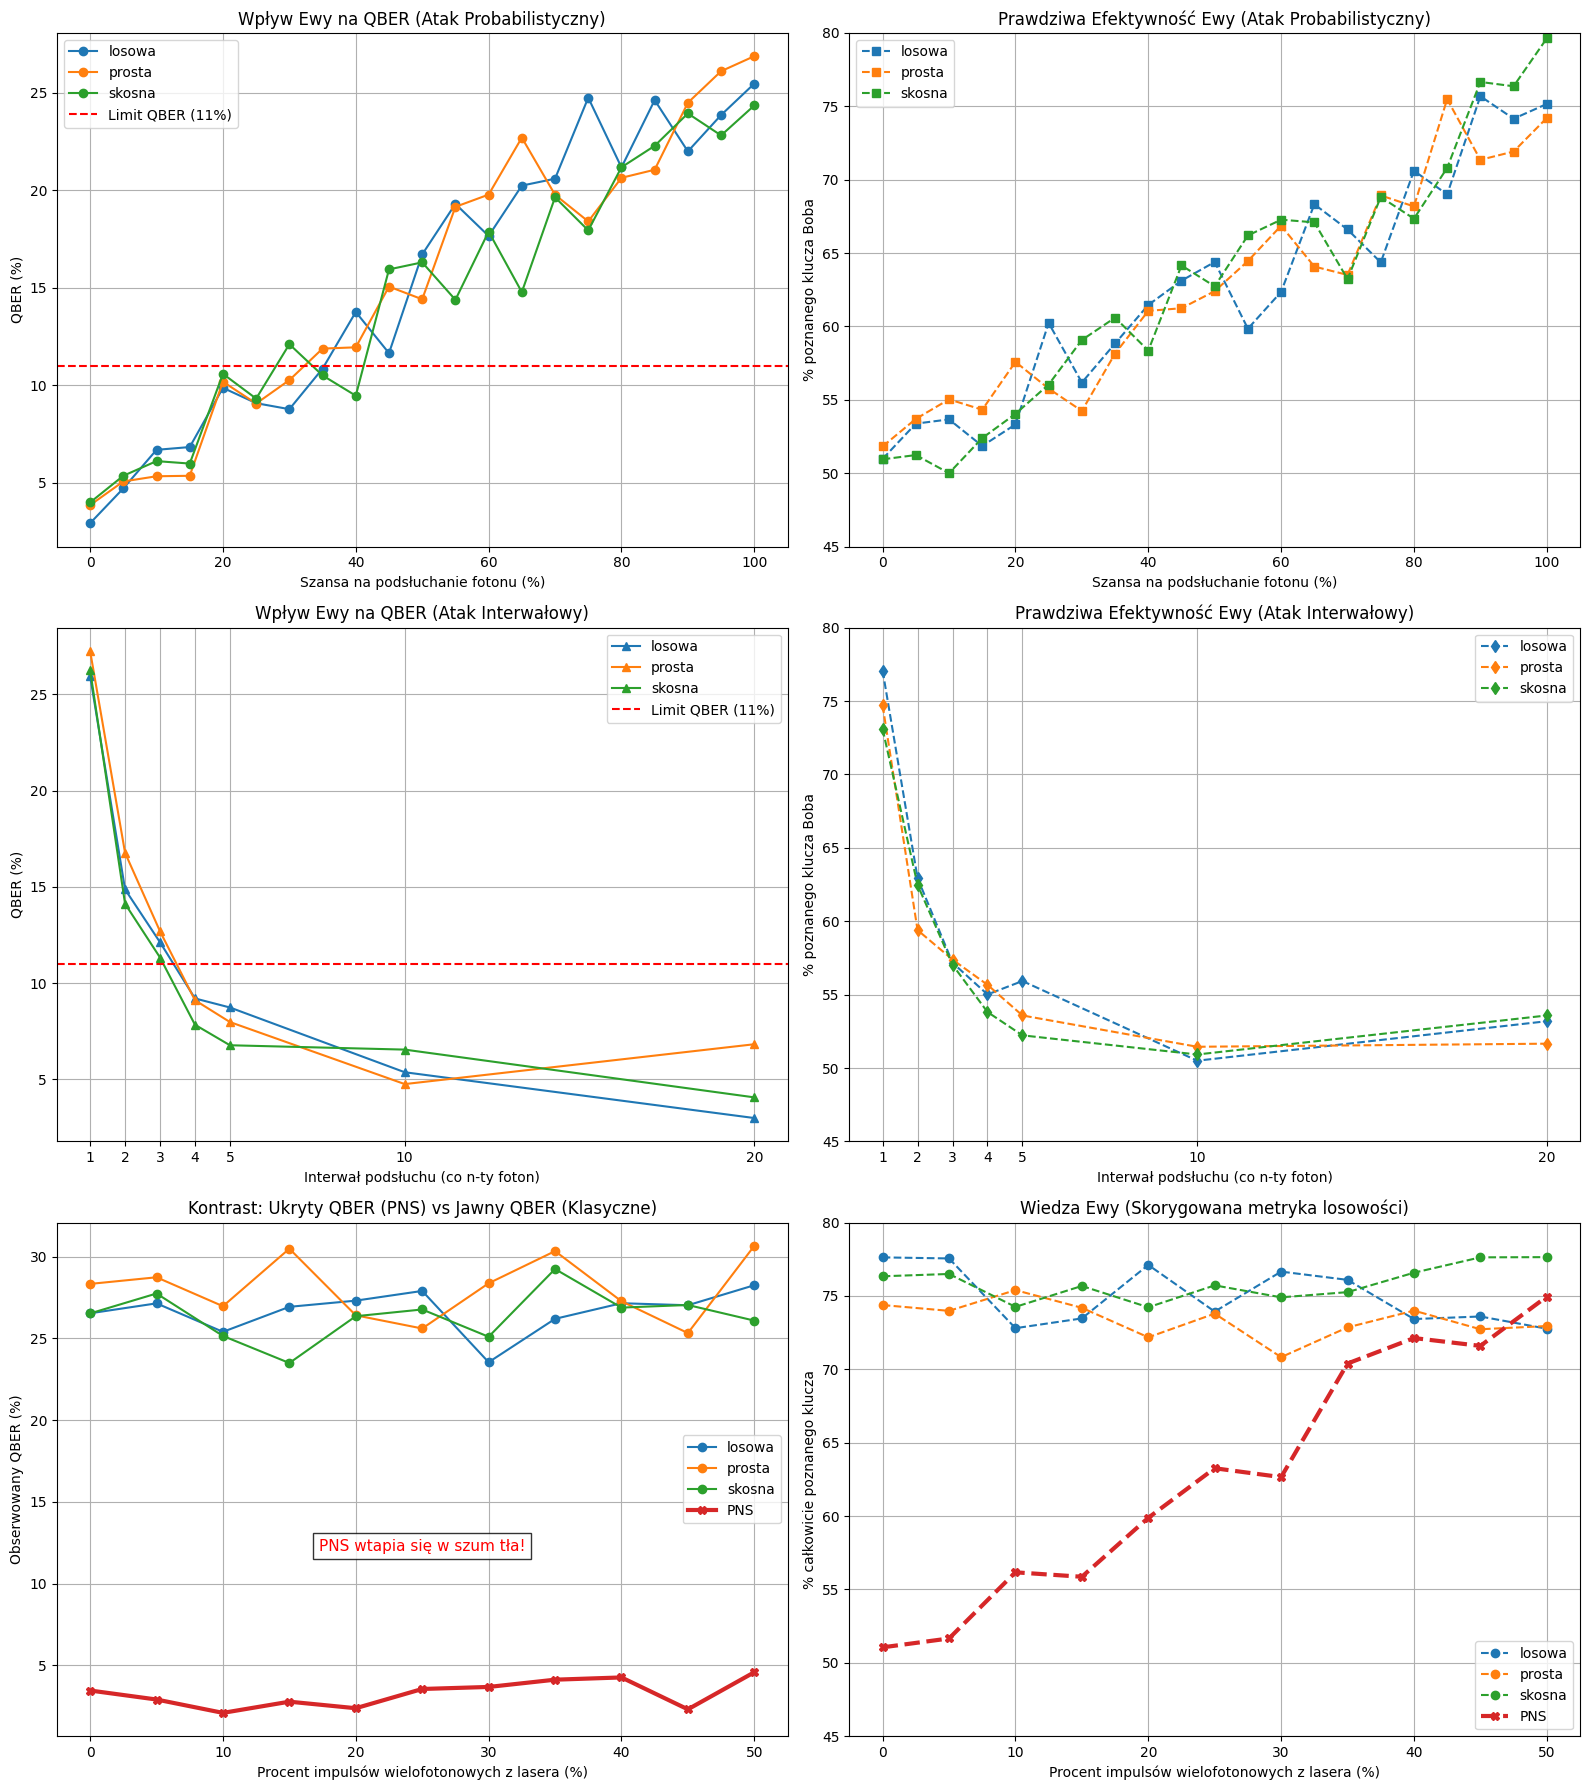


--- RĘCZNA SYMULACJA GŁÓWNA ---


In [ ]:
import os
import random
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

# Źródło

class QRNGFileGenerator:
    def __init__(self, filepath):
        self.filepath = filepath
        self.file = open(filepath, 'rb')
        losowy_start = random.randint(0, 1024)
        self.file.seek(losowy_start)
        self.buffer = 0
        self.bit_pos = 0

    def get_next_bit(self):
        while True:
            if self.bit_pos == 0:
                byte = self.file.read(1)
                if not byte:
                    self.file.seek(0)
                    byte = self.file.read(1)


                if byte in [b'0', b'1']:
                    return int(byte)
                elif byte in [b'\n', b'\r', b' ']:
                    continue

                self.buffer = int.from_bytes(byte, byteorder='big')
                self.bit_pos = 8

            self.bit_pos -= 1
            return (self.buffer >> self.bit_pos) & 1

    def close(self):
        self.file.close()


# Źródło nieidealne

def alicja_przygotuj_fotony(ilosc_fotonow, qrng, source_error_rate=0.01, p_multi=0.1):
    obwody_kwantowe = []
    bity_alicji = []
    bazy_alicji = []
    lista_multi = []

    for _ in range(ilosc_fotonow):
        wartosc_bitu = qrng.get_next_bit()
        baza_pomiarowa = qrng.get_next_bit()
        bity_alicji.append(wartosc_bitu)
        bazy_alicji.append(baza_pomiarowa)

        wielokrotnosc = 2 if random.random() < p_multi else 1
        lista_multi.append(wielokrotnosc)

        qc = QuantumCircuit(1)
        if wartosc_bitu == 1: qc.x(0)
        if baza_pomiarowa == 1: qc.h(0)

        if random.random() < source_error_rate:
            qc.x(0)
        obwody_kwantowe.append(qc)

    return obwody_kwantowe, bity_alicji, bazy_alicji, lista_multi

# Podsłuch Ewy

def podsłuch_ewy(obwody_kwantowe, qrng, bity_alicji, lista_multi, strategia='losowa', tryb='probabilistyczny', prawdopodobienstwo=0.1, start_krok=0, interwal=2):
    obwody_po_ewie = []
    bity_ewy = []
    bazy_ewy = []

    for i, qc in enumerate(obwody_kwantowe):
        if strategia == 'PNS':
            if lista_multi[i] > 1:
                bity_ewy.append(bity_alicji[i])
                bazy_ewy.append(-1)
                obwody_po_ewie.append(qc.copy())
            else:
                bity_ewy.append(None)
                bazy_ewy.append(None)
                obwody_po_ewie.append(qc.copy())
            continue

        podsłuchuje = False
        if tryb == 'probabilistyczny':
            if random.random() < prawdopodobienstwo: podsłuchuje = True
        elif tryb == 'sekwencyjny':
            if i >= start_krok: podsłuchuje = True
        elif tryb == 'interwalowy':
            if interwal > 0 and (i + 1) % interwal == 0: podsłuchuje = True

        if not podsłuchuje:
            obwody_po_ewie.append(qc.copy())
            bity_ewy.append(None)
            bazy_ewy.append(None)
            continue

        if strategia == 'prosta': baza = 0
        elif strategia == 'skosna': baza = 1
        else: baza = qrng.get_next_bit()

        bazy_ewy.append(baza)

        qc_ewa = qc.copy()
        if baza == 1: qc_ewa.h(0)
        wektor_stanu = Statevector(qc_ewa)
        zmierzony_wynik_str, _ = wektor_stanu.measure()
        zmierzony_bit = int(zmierzony_wynik_str)
        bity_ewy.append(zmierzony_bit)

        nowy_foton = QuantumCircuit(1)
        if zmierzony_bit == 1: nowy_foton.x(0)
        if baza == 1: nowy_foton.h(0)
        obwody_po_ewie.append(nowy_foton)

    return obwody_po_ewie, bity_ewy, bazy_ewy

# Kanał kwantowy

def kanal_kwantowy(obwody_kwantowe, channel_error_rate=0.03):
    obwody_po_przejsciu = []
    for qc in obwody_kwantowe:
        qc_kanal = qc.copy()
        if random.random() < channel_error_rate:
            rodzaj_bledu = random.choice(['X', 'Y', 'Z'])
            if rodzaj_bledu == 'X': qc_kanal.x(0)
            elif rodzaj_bledu == 'Y': qc_kanal.y(0)
            elif rodzaj_bledu == 'Z': qc_kanal.z(0)
        obwody_po_przejsciu.append(qc_kanal)
    return obwody_po_przejsciu

# Pomiar

def bob_pomiar(obwody_po_kanale, qrng, detector_error_rate=0.01):
    bazy_boba = []
    wyniki_boba = []
    for qc in obwody_po_kanale:
        baza_pomiarowa = qrng.get_next_bit()
        bazy_boba.append(baza_pomiarowa)

        qc_pomiar = qc.copy()
        if baza_pomiarowa == 1: qc_pomiar.h(0)

        wektor_stanu = Statevector(qc_pomiar)
        zmierzony_wynik_str, _ = wektor_stanu.measure()
        bit = int(zmierzony_wynik_str)

        if random.random() < detector_error_rate:
            bit ^= 1

        wyniki_boba.append(bit)
    return wyniki_boba, bazy_boba

# Elementy warstwy klasycznej

def uzgodnij_klucz(bity_alicji, bazy_alicji, bity_boba, bazy_boba):
    klucz_alicji, klucz_boba = [], []
    for i in range(len(bazy_alicji)):
        if bazy_alicji[i] == bazy_boba[i]:
            klucz_alicji.append(bity_alicji[i])
            klucz_boba.append(bity_boba[i])
    return klucz_alicji, klucz_boba

def korekcja_bledow(klucz_alicji, klucz_boba, rozmiar_bloku=4):
    ostateczny_klucz_alicji, ostateczny_klucz_boba = [], []
    for i in range(0, len(klucz_alicji), rozmiar_bloku):
        blok_a = klucz_alicji[i:i+rozmiar_bloku]
        blok_b = klucz_boba[i:i+rozmiar_bloku]
        if len(blok_a) < rozmiar_bloku: continue

        if sum(blok_a) % 2 == sum(blok_b) % 2:
            ostateczny_klucz_alicji.extend(blok_a[:-1])
            ostateczny_klucz_boba.extend(blok_b[:-1])
    return ostateczny_klucz_alicji, ostateczny_klucz_boba

# Wykresy

def generuj_wykresy(qrng, p_zrodla, p_kanalu, p_detektora):
    print("\nGenerowanie zaawansowanej analizy statystycznej... (Proszę czekać, symulacja w toku)")

    ilosc_symulacji = 1000
    strategie_podstawowe = ['losowa', 'prosta', 'skosna']
    strategie_wszystkie = ['losowa', 'prosta', 'skosna', 'PNS']

    prawdopodobienstwa = [i/20.0 for i in range(21)]
    interwaly = [1, 2, 3, 4, 5, 10, 20]

    wyniki_qber_prob = {strat: [] for strat in strategie_podstawowe}
    wyniki_wiedza_prob = {strat: [] for strat in strategie_podstawowe}
    wyniki_qber_int = {strat: [] for strat in strategie_podstawowe}
    wyniki_wiedza_int = {strat: [] for strat in strategie_podstawowe}

    # --- FUNKCJA POMOCNICZA: Poprawna matematycznie wiedza Ewy ---
    def oblicz_wiedze_ewy(b_a, bazy_a, b_b, bazy_b, b_e):
        poprawne_ewy = 0
        uzgodnionych_bitow = 0
        for i in range(len(bazy_a)):
            if bazy_a[i] == bazy_b[i]: # Skupiamy się na sifted key
                uzgodnionych_bitow += 1
                if b_e[i] is not None:
                    if b_e[i] == b_a[i]: poprawne_ewy += 1
                else:
                    # RZUT MONETĄ: Ewa nie przechwyciła, więc musi zgadywać w ciemno (szansa 50%)
                    if random.random() < 0.5: poprawne_ewy += 1
        return (poprawne_ewy / uzgodnionych_bitow) * 100 if uzgodnionych_bitow > 0 else 0

    # --- A. Probabilistyczny ---
    for p_ewy in prawdopodobienstwa:
        for strat in strategie_podstawowe:
            f_a, b_a, bazy_a, l_multi = alicja_przygotuj_fotony(ilosc_symulacji, qrng, p_zrodla, 0.0)
            f_e, b_e, bazy_e = podsłuch_ewy(f_a, qrng, b_a, l_multi, strategia=strat, tryb='probabilistyczny', prawdopodobienstwo=p_ewy)
            f_b = kanal_kwantowy(f_e, channel_error_rate=p_kanalu)
            b_b, bazy_b = bob_pomiar(f_b, qrng, detector_error_rate=p_detektora)
            k_a, k_b = uzgodnij_klucz(b_a, bazy_a, b_b, bazy_b)

            bledy = sum(1 for a, b in zip(k_a, k_b) if a != b)
            wyniki_qber_prob[strat].append((bledy / len(k_a)) * 100 if len(k_a) > 0 else 0)
            wyniki_wiedza_prob[strat].append(oblicz_wiedze_ewy(b_a, bazy_a, b_b, bazy_b, b_e))

    # --- B. Interwałowy ---
    for inter in interwaly:
        for strat in strategie_podstawowe:
            f_a, b_a, bazy_a, l_multi = alicja_przygotuj_fotony(ilosc_symulacji, qrng, p_zrodla, 0.0)
            f_e, b_e, bazy_e = podsłuch_ewy(f_a, qrng, b_a, l_multi, strategia=strat, tryb='interwalowy', interwal=inter)
            f_b = kanal_kwantowy(f_e, channel_error_rate=p_kanalu)
            b_b, bazy_b = bob_pomiar(f_b, qrng, detector_error_rate=p_detektora)
            k_a, k_b = uzgodnij_klucz(b_a, bazy_a, b_b, bazy_b)

            bledy = sum(1 for a, b in zip(k_a, k_b) if a != b)
            wyniki_qber_int[strat].append((bledy / len(k_a)) * 100 if len(k_a) > 0 else 0)
            wyniki_wiedza_int[strat].append(oblicz_wiedze_ewy(b_a, bazy_a, b_b, bazy_b, b_e))

    # --- C. SYMULACJA ATAKU PNS I KLASYCZNYCH W ZALEŻNOŚCI OD LASERA ---
    p_multi_wartosci = [i/20.0 for i in range(11)]
    wyniki_qber_multi = {strat: [] for strat in strategie_wszystkie}
    wyniki_wiedza_multi = {strat: [] for strat in strategie_wszystkie}

    print("\n===========================================================================================================")
    print(f"RAPORT Z SYMULACJI: WPŁYW JAKOŚCI LASERA NA ATAKI (Próbka: {ilosc_symulacji} fotonów)")
    print("===========================================================================================================")
    print(f"{'Multi-fotony':<14} | {'QBER (PNS)':<12} | {'QBER (Los)':<12} | {'QBER (Prost)':<12} | {'QBER (Skos)':<12} | {'Wiedza (PNS)':<14} | {'Wiedz (Los)':<12} | {'Wiedz (Prost)':<14} | {'Wiedz (Skos)':<12}")
    print("-" * 135)

    for p_multi in p_multi_wartosci:
        for strat in strategie_wszystkie:
            f_a, b_a, bazy_a, l_multi = alicja_przygotuj_fotony(ilosc_symulacji, qrng, p_zrodla, p_multi)

            tryb_ewy = 'probabilistyczny' if strat != 'PNS' else 'probabilistyczny'
            prob_ewy = 1.0 if strat != 'PNS' else 1.0

            f_e, b_e, bazy_e = podsłuch_ewy(f_a, qrng, b_a, l_multi, strategia=strat, tryb=tryb_ewy, prawdopodobienstwo=prob_ewy)
            f_b = kanal_kwantowy(f_e, channel_error_rate=p_kanalu)
            b_b, bazy_b = bob_pomiar(f_b, qrng, detector_error_rate=p_detektora)
            k_a, k_b = uzgodnij_klucz(b_a, bazy_a, b_b, bazy_b)

            bledy = sum(1 for a, b in zip(k_a, k_b) if a != b)
            wyniki_qber_multi[strat].append((bledy / len(k_a)) * 100 if len(k_a) > 0 else 0)
            wyniki_wiedza_multi[strat].append(oblicz_wiedze_ewy(b_a, bazy_a, b_b, bazy_b, b_e))

        print(f"{p_multi*100:>12.0f}% | {wyniki_qber_multi['PNS'][-1]:>11.2f}% | {wyniki_qber_multi['losowa'][-1]:>11.2f}% | {wyniki_qber_multi['prosta'][-1]:>11.2f}% | {wyniki_qber_multi['skosna'][-1]:>11.2f}% | {wyniki_wiedza_multi['PNS'][-1]:>13.2f}% | {wyniki_wiedza_multi['losowa'][-1]:>11.2f}% | {wyniki_wiedza_multi['prosta'][-1]:>13.2f}% | {wyniki_wiedza_multi['skosna'][-1]:>11.2f}%")

    # --- RYSOWANIE SIATKI WYKRESÓW (3x2) ---
    fig, axs = plt.subplots(3, 2, figsize=(16, 18))
    os_x_prob = [p*100 for p in prawdopodobienstwa]

    for strat in strategie_podstawowe:
        axs[0,0].plot(os_x_prob, wyniki_qber_prob[strat], marker='o', label=f'{strat}')
        axs[0,1].plot(os_x_prob, wyniki_wiedza_prob[strat], marker='s', linestyle='--', label=f'{strat}')

    axs[0,0].set_title('Wpływ Ewy na QBER (Atak Probabilistyczny)')
    axs[0,0].set_xlabel('Szansa na podsłuchanie fotonu (%)')
    axs[0,0].set_ylabel('QBER (%)')
    axs[0,0].axhline(y=11, color='r', linestyle='--', label='Limit QBER (11%)')
    axs[0,0].grid(True); axs[0,0].legend()

    axs[0,1].set_title('Prawdziwa Efektywność Ewy (Atak Probabilistyczny)')
    axs[0,1].set_xlabel('Szansa na podsłuchanie fotonu (%)')
    axs[0,1].set_ylabel('% poznanego klucza Boba')
    axs[0,1].set_ylim([45, 80]) # Skala poprawna dla binarnej entropii
    axs[0,1].grid(True); axs[0,1].legend()

    for strat in strategie_podstawowe:
        axs[1,0].plot(interwaly, wyniki_qber_int[strat], marker='^', label=f'{strat}')
        axs[1,1].plot(interwaly, wyniki_wiedza_int[strat], marker='d', linestyle='--', label=f'{strat}')

    axs[1,0].set_title('Wpływ Ewy na QBER (Atak Interwałowy)')
    axs[1,0].set_xlabel('Interwał podsłuchu (co n-ty foton)')
    axs[1,0].set_ylabel('QBER (%)')
    axs[1,0].set_xticks(interwaly)
    axs[1,0].axhline(y=11, color='r', linestyle='--', label='Limit QBER (11%)')
    axs[1,0].grid(True); axs[1,0].legend()

    axs[1,1].set_title('Prawdziwa Efektywność Ewy (Atak Interwałowy)')
    axs[1,1].set_xlabel('Interwał podsłuchu (co n-ty foton)')
    axs[1,1].set_ylabel('% poznanego klucza Boba')
    axs[1,1].set_xticks(interwaly)
    axs[1,1].set_ylim([45, 80])
    axs[1,1].grid(True); axs[1,1].legend()

    os_x_pns = [p*100 for p in p_multi_wartosci]
    for strat in strategie_wszystkie:
        marker = 'X' if strat == 'PNS' else 'o'
        linewidth = 3 if strat == 'PNS' else 1.5
        axs[2,0].plot(os_x_pns, wyniki_qber_multi[strat], marker=marker, linewidth=linewidth, label=f'{strat}')
        axs[2,1].plot(os_x_pns, wyniki_wiedza_multi[strat], marker=marker, linewidth=linewidth, linestyle='--', label=f'{strat}')

    axs[2,0].set_title('Kontrast: Ukryty QBER (PNS) vs Jawny QBER (Klasyczne)')
    axs[2,0].set_xlabel('Procent impulsów wielofotonowych z lasera (%)')
    axs[2,0].set_ylabel('Obserwowany QBER (%)')
    axs[2,0].grid(True); axs[2,0].legend()
    axs[2,0].text(25, 12, "PNS wtapia się w szum tła!", ha='center', color='red', fontsize=11, bbox=dict(facecolor='white', alpha=0.8))

    axs[2,1].set_title('Wiedza Ewy (Skorygowana metryka losowości)')
    axs[2,1].set_xlabel('Procent impulsów wielofotonowych z lasera (%)')
    axs[2,1].set_ylabel('% całkowicie poznanego klucza')
    axs[2,1].set_ylim([45, 80])
    axs[2,1].grid(True); axs[2,1].legend()

    plt.tight_layout()
    plt.show()

# ==========================================
# TEST ZINTEGROWANY
# ==========================================
if __name__ == "__main__":
    lista_plikow = [f for f in os.listdir('.') if f.endswith('.dat')]
    if not lista_plikow and os.path.exists('qng'):
        lista_plikow = [os.path.join('qng', f) for f in os.listdir('qng') if f.endswith('.dat')]
    if not lista_plikow:
        raise FileNotFoundError("Brak plików z losowością! Przeciągnij pliki QNGFile.dat do Colaba.")

    wybrany_plik = random.choice(lista_plikow)
    print(f"Wybrano plik QRNG: {wybrany_plik}\n")

    print("--- FIZYCZNE PARAMETRY ŚRODOWISKA ---")
    w1 = input("Błąd źródła (Laser) - domyślnie 0.01 (1%): ").strip()
    p_zrodla = float(w1) if w1 else 0.01

    w2 = input("Błąd światłowodu (Dekohorencja) - domyślnie 0.03 (3%): ").strip()
    p_kanalu = float(w2) if w2 else 0.03

    w3 = input("Błąd detektorów Boba (Dark counts) - domyślnie 0.01 (1%): ").strip()
    p_detektora = float(w3) if w3 else 0.01

    czy_wykresy = input("\nCzy chcesz najpierw wygenerować tabele i wykresy analizy strategii Ewy? (t/n) [n]: ").strip().lower()
    moj_qrng = QRNGFileGenerator(wybrany_plik)

    if czy_wykresy == 't':
        generuj_wykresy(moj_qrng, p_zrodla, p_kanalu, p_detektora)

    print("\n--- RĘCZNA SYMULACJA GŁÓWNA ---")
    w_ilosc = input("Podaj ilość fotonów (Enter dla 50): ").strip()
    ilosc = int(w_ilosc) if w_ilosc else 50

    w_multi = input("Prawdopodobieństwo impulsu wielofotonowego (np. 0.15 to 15%) [0.1]: ").strip()
    p_multi_main = float(w_multi) if w_multi else 0.1

    wybor_ewy = input("Czy Ewa ma podsłuchiwać linię? (t/n) [n]: ").strip().lower()
    czy_ewa_aktywna = (wybor_ewy == 't')

    if czy_ewa_aktywna:
        print("Dostępne strategie Ewy: 1='losowa', 2='prosta', 3='skosna', 4='PNS' (Atak bezszelestny)")
        strat_input = input("Wybierz strategię (1/2/3/4) [1]: ").strip()

        if strat_input == '2': strategia_ewy = 'prosta'
        elif strat_input == '3': strategia_ewy = 'skosna'
        elif strat_input == '4': strategia_ewy = 'PNS'
        else: strategia_ewy = 'losowa'

        if strategia_ewy != 'PNS':
            print("Tryb podsłuchu: 1='probabilistyczny' (X% fotonów), 2='interwalowy' (co n-ty foton)")
            tryb_input = input("Wybierz tryb (1/2) [1]: ").strip()

            if tryb_input == '2':
                tryb_ewy = 'interwalowy'
                int_input = input("Podaj interwał (np. 2 dla co drugiego, 4 dla co czwartego) [2]: ").strip()
                interwal_ewy = int(int_input) if int_input else 2
                prob_ewy = 0.0
            else:
                tryb_ewy = 'probabilistyczny'
                interwal_ewy = 0
                prob_input = input("Podaj ułamek podsłuchiwanych fotonów (np. 0.2) [0.5]: ").strip()
                prob_ewy = float(prob_input) if prob_input else 0.5
        else:
            tryb_ewy, prob_ewy, interwal_ewy = 'PNS', 1.0, 1
    else:
        strategia_ewy, tryb_ewy, prob_ewy, interwal_ewy = 'losowa', 'probabilistyczny', 0.0, 0

    fotony_alicji, bity_alicji, bazy_alicji, lista_multi_main = alicja_przygotuj_fotony(ilosc, moj_qrng, source_error_rate=p_zrodla, p_multi=p_multi_main)

    if czy_ewa_aktywna:
        fotony_po_ewie, bity_ewy, bazy_ewy = podsłuch_ewy(
            fotony_alicji, moj_qrng, bity_alicji, lista_multi_main, strategia=strategia_ewy, tryb=tryb_ewy, prawdopodobienstwo=prob_ewy, interwal=interwal_ewy)
    else:
        fotony_po_ewie = fotony_alicji
        bity_ewy = [None] * ilosc

    fotony_od_boba = kanal_kwantowy(fotony_po_ewie, channel_error_rate=p_kanalu)
    bity_boba, bazy_boba = bob_pomiar(fotony_od_boba, moj_qrng, detector_error_rate=p_detektora)
    surowy_klucz_alicji, surowy_klucz_boba = uzgodnij_klucz(bity_alicji, bazy_alicji, bity_boba, bazy_boba)

    ilosc_po_siftingu = len(surowy_klucz_alicji)
    bledy_przed_korekcja = sum(1 for a, b in zip(surowy_klucz_alicji, surowy_klucz_boba) if a != b)
    qber_poczatkowy = (bledy_przed_korekcja / ilosc_po_siftingu) * 100 if ilosc_po_siftingu > 0 else 0

    czysty_klucz_alicji, czysty_klucz_boba = korekcja_bledow(surowy_klucz_alicji, surowy_klucz_boba, rozmiar_bloku=4)
    ilosc_po_korekcji = len(czysty_klucz_alicji)
    bledy_po_korekcji = sum(1 for a, b in zip(czysty_klucz_alicji, czysty_klucz_boba) if a != b)
    qber_koncowy = (bledy_po_korekcji / ilosc_po_korekcji) * 100 if ilosc_po_korekcji > 0 else 0

    print("\n==========================================")
    print(f"RAPORT Z TRANSMISJI ({ilosc} fotonów)")
    print(f"Szum: Laser {p_zrodla*100}% | Światłowód {p_kanalu*100}% | Detektory {p_detektora*100}% | Multi-fotony: {p_multi_main*100}%")
    if czy_ewa_aktywna:
        podsluchano_ile = sum(1 for b in bity_ewy if b is not None)
        print(f"EWA: Strategia '{strategia_ewy}'. Używając luk sprzętowych odczytała poprawnie z pewnością {podsluchano_ile} bitów!")
    print("==========================================")
    print(f"QBER SUROWY (Przed korekcją): {qber_poczatkowy:.2f}% ({bledy_przed_korekcja} błędów na {ilosc_po_siftingu} bitów)")
    print(f"QBER CZYSTY (Po korekcji):    {qber_koncowy:.2f}% ({bledy_po_korekcji} błędów na {ilosc_po_korekcji} bitów)")
    print("==========================================\n")

    moj_qrng.close()